# Siddak Marwaha
# CMSE 381 HW6

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
import statsmodels.api as sm

Q1

In [2]:
toy_data = pd.read_csv('polynomial-toydata.csv')
X = toy_data['x'].values.reshape(-1, 1)
y = toy_data['y'].values
toy_data.shape

(100, 3)

(A) Polynomial Regression

i) **Degree** is the hyperparameter

ii)

In [3]:
degrees = range(1, 15)
k_folds = KFold(n_splits=5, shuffle=True, random_state=123)
best_degree = 0
lowest_mse = float('inf')

for degree in degrees:
    mse_list = []
    poly = PolynomialFeatures(degree)
    for train_index, test_index in k_folds.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        X_poly_train = poly.fit_transform(X_train)
        X_poly_test = poly.transform(X_test)
        
        model = LinearRegression().fit(X_poly_train, y_train)
        y_pred = model.predict(X_poly_test)
        mse_list.append(mean_squared_error(y_test, y_pred))
    
    avg_mse = np.mean(mse_list)
    if avg_mse < lowest_mse:
        lowest_mse = avg_mse
        best_degree = degree

In [4]:
print('Best Degree found was:', best_degree, '\n', 'Lowest MSE:', lowest_mse)

Best Degree found was: 4 
 Lowest MSE: 83.04349309526285


iii)

In [5]:
# Train with the best degree on the full data
poly = PolynomialFeatures(best_degree)
X_poly = poly.fit_transform(X)
model_poly = LinearRegression().fit(X_poly, y)


(B) Step Functions

i) The **number of cuts** is the hyperparameter

ii)

In [6]:
cuts_range = range(2, 15)
best_cut = 0
lowest_mse = float('inf')

for cut in cuts_range:
    mse_list = []
    toy_data_cut, bins = pd.cut(toy_data['x'], cut, retbins=True)
    X_step = pd.get_dummies(toy_data_cut)
    X_step = X_step.values
    
    for train_index, test_index in k_folds.split(X_step):
        X_train, X_test = X_step[train_index], X_step[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        model = LinearRegression().fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mse_list.append(mean_squared_error(y_test, y_pred))
    
    avg_mse = np.mean(mse_list)
    if avg_mse < lowest_mse:
        lowest_mse = avg_mse
        best_cut = cut

In [7]:
print('Best number of cuts found was:', best_cut, '\n', 'Lowest MSE:', lowest_mse)

Best number of cuts found was: 13 
 Lowest MSE: 279.6851068815242


iii)

In [8]:
# Train the final step function model
toy_data_cut, bins = pd.cut(toy_data['x'], best_cut, retbins=True)
X_step = pd.get_dummies(toy_data_cut)
model_step = LinearRegression().fit(X_step, y)


(C) Cubic splines

i) The **number of knots** is the hyperparameter

ii)

In [9]:
knots_range = range(2, 15)
best_knots = 0
lowest_mse = float('inf')

for knots in knots_range:
    mse_list = []
    splt = SplineTransformer(n_knots=knots, degree=3)
    X_spline = splt.fit_transform(X)
    
    for train_index, test_index in k_folds.split(X_spline):
        X_train, X_test = X_spline[train_index], X_spline[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        model = LinearRegression().fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mse_list.append(mean_squared_error(y_test, y_pred))
    
    avg_mse = np.mean(mse_list)
    if avg_mse < lowest_mse:
        lowest_mse = avg_mse
        best_knots = knots

In [10]:
print('Best number of knots found was:', best_knots, '\n', 'Lowest MSE:', lowest_mse)

Best number of knots found was: 4 
 Lowest MSE: 85.17988793560771


iii)

In [11]:
# Train final cubic spline model
splt = SplineTransformer(n_knots=best_knots, degree=3)
X_spline = splt.fit_transform(X)
model_spline = LinearRegression().fit(X_spline, y)


**Plotting**

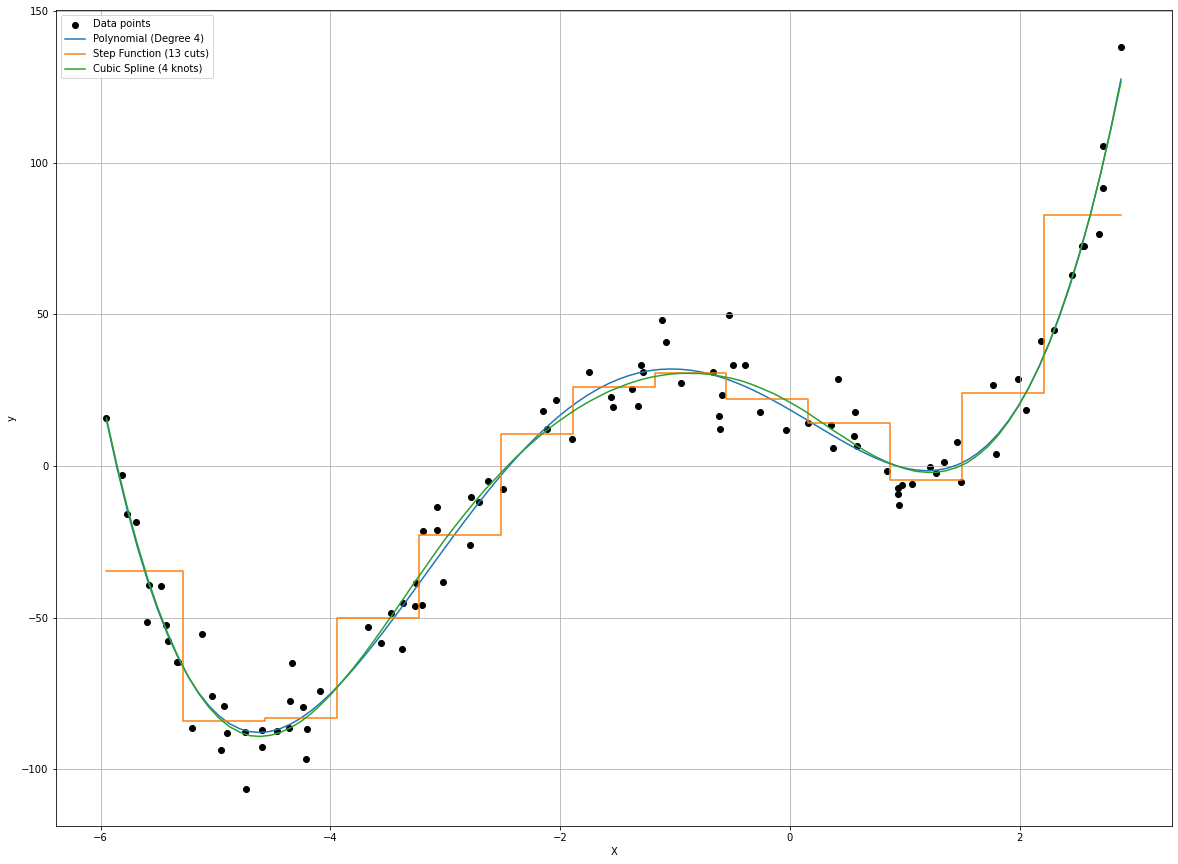

In [15]:
# Plot data
plt.figure(figsize=(20,15))
plt.scatter(X, y, label='Data points', color='black')

# Polynomial Regression
X_plot = np.linspace(min(X), max(X), 100).reshape(-1, 1)
y_poly = model_poly.predict(PolynomialFeatures(best_degree).fit_transform(X_plot))
plt.plot(X_plot, y_poly, label=f'Polynomial (Degree {best_degree})')

# Step Function
toy_data_cut, _ = pd.cut(X_plot.flatten(), best_cut, retbins=True)
X_plot_step = pd.get_dummies(toy_data_cut)
y_step = model_step.predict(X_plot_step)
plt.step(X_plot.flatten(), y_step, where='mid', label=f'Step Function ({best_cut} cuts)')

# Cubic Spline
X_plot_spline = SplineTransformer(n_knots=best_knots, degree=3).fit_transform(X_plot)
y_spline = model_spline.predict(X_plot_spline)
plt.plot(X_plot, y_spline, label=f'Cubic Spline ({best_knots} knots)')

plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()

Cubic Spline with 4 knots and Polynomial Regression with a degree of 4 seemed to give better results than the Step Function. I would choose **Polynomial Regression** since it had the lowest MSE with 83.04 while cubic spline had an MSE of 85.18 while Step Function had an MSE of 279.68.

Q2

A)

i)

Piecewise fn for C0, C1, and C2:

C0 = 

    { 1, if x<3
    0, otherwise}
    
C1 = 

    { 1, if 3<=x<7
    0, otherwise}
    
C2 = 

    { 1, if x>=7
    0, otherwise}

GRAPH IN ATTACHED PICTURES

ii)

f(x) = 2 + 3 * C_1(X) − 1 * C_2(X)

GRAPH IN ATTACHED PICTURES

B)

i)

ANSWER IN ATTACHED PICTURES, **knot at 4**

ii)

A cubic spline must satisfy these conditions:

- The function f(x) is continuous at the knot.
- The first derivative f'(x) is continuous at the knot.
- The second derivative f''(x) is continuous at the knot.


iii)

Let’s confirm that f(x) as defined above meets these criteria at X=4:
- Both parts of f(x) give the same value at X=4, so f(x) is continuous at the knot.
- Calculating f'(x) on both sides of X=4, we would observe that the first derivatives match.

    LHS: f(x) = 1-4x + 9x^2, f(4) = 129

    RHS: f(x) = 9x^2 - 4x - 12(x-4)^2 + 1, f(4) = 129


- Similarly, calculating f''(x) shows that the second derivatives are equal at X=4.

    LHS: f(x) = 18x-4, f(4) = 68

    RHS: f(x) = 92 - 6x, f(4) = 68

Thus, f(x) meets the requirements